In [1]:
!pip install -q transformers==4.37.2 accelerate bitsandbytes matplotlib opencv-python scipy PyMuPID
!pip install -q fitz PyMuPDF einops timm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 3.3 MB/s eta 0:00:00
ERROR: Could not find a version that satisfies the requirement PyMuPID (from versions: none)
ERROR: No matching distribution found for PyMuPID
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 84.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 114.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.7/110.7 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.9/425.9 kB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 615.4/615.4 kB 45.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 118.4 MB/s eta 0:00:00


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
import cv2
from torchvision.models import resnet18, ResNet18_Weights
from einops import rearrange

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используется устройство: {device}")

Используется устройство: cuda


In [3]:
class TAM(nn.Module):
    def __init__(self, num_tokens=49, num_classes=10, embed_dim=512, num_heads=8):
        super().__init__()
        self.num_tokens = num_tokens
        self.num_classes = num_classes
        self.embed_dim = embed_dim
        self.num_heads = num_heads

        self.query = nn.Linear(embed_dim, embed_dim)
        self.key = nn.Linear(embed_dim, embed_dim)
        self.value = nn.Linear(embed_dim, embed_dim)

        self.class_token = nn.Parameter(torch.randn(1, 1, embed_dim))

        self.output_proj = nn.Linear(embed_dim, num_classes)

        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, features, return_attention=False):
        batch, channels, h, w = features.shape
        tokens = rearrange(features, 'b c h w -> b (h w) c')
        class_token = self.class_token.expand(batch, -1, -1)
        tokens = torch.cat([class_token, tokens], dim=1)

        tokens = self.norm(tokens)

        Q = self.query(tokens)
        K = self.key(tokens)
        V = self.value(tokens)

        Q = rearrange(Q, 'b n (h d) -> b h n d', h=self.num_heads)
        K = rearrange(K, 'b n (h d) -> b h n d', h=self.num_heads)
        V = rearrange(V, 'b n (h d) -> b h n d', h=self.num_heads)

        attention = F.softmax(Q @ K.transpose(-2, -1) / (self.embed_dim ** 0.5), dim=-1)

        out = attention @ V
        out = rearrange(out, 'b h n d -> b n (h d)')

        logits = self.output_proj(out[:, 0, :])

        if return_attention:
            attention_map = attention.mean(dim=1)[:, 0, 1:]
            attention_map = attention_map.view(batch, h, w)
            return logits, attention_map

        return logits

In [4]:
class TAMVisualizer:
    def __init__(self, model, target_layer='layer4', num_classes=10):
        self.model = model
        self.target_layer = target_layer
        self.num_classes = num_classes
        self.features = None
        self.tam = None
        self._register_hook()

    def _register_hook(self):
        def hook(module, input, output):
            self.features = output.detach()

        for name, module in self.model.named_modules():
            if name == self.target_layer:
                module.register_forward_hook(hook)
                return
        for name, module in self.model.named_modules():
            if isinstance(module, nn.Conv2d) and 'layer' in name:
                module.register_forward_hook(hook)
                return

    def _init_tam(self, features):
        batch, channels, h, w = features.shape
        num_tokens = h * w

        self.tam = TAM(
            num_tokens=num_tokens,
            num_classes=self.num_classes,
            embed_dim=channels
        ).to(device)

        return True

    def generate_heatmap(self, image, target_class=None):
        self.model.eval()

        image = image.to(device)
        image.requires_grad = True

        with torch.no_grad():
            _ = self.model(image)
        if self.features is None:
            return None, None, None

        features = self.features.clone()
        features.requires_grad = True

        if self.tam is None:
            self._init_tam(features)

        self.tam.train()
        logits, attention_map = self.tam(features, return_attention=True)

        if target_class is None:
            target_class = torch.argmax(logits, dim=1).item()

        self.tam.zero_grad()
        logits[0, target_class].backward()

        attn_map = attention_map.detach().cpu().numpy()[0]

        attn_map = (attn_map - attn_map.min()) / (attn_map.max() - attn_map.min() + 1e-8)

        confidence = F.softmax(logits, dim=1)[0, target_class].item()

        return attn_map, target_class, confidence

In [5]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                        download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=1, shuffle=True)

classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

print(f"Загружено {len(testset)} изображений")

100%|██████████| 170M/170M [00:03<00:00, 42.9MB/s]


Загружено 10000 изображений


In [6]:
model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Linear(model.fc.in_features, 10)
model = model.to(device)
model.eval()

visualizer = TAMVisualizer(model, target_layer='layer4', num_classes=10)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 184MB/s]


In [7]:
def denormalize_image(tensor):
    if tensor.requires_grad:
        tensor = tensor.detach()

    img = tensor.squeeze().cpu().numpy().transpose(1, 2, 0)
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    img = std * img + mean
    img = np.clip(img, 0, 1)
    return img


def visualize_heatmap(image, heatmap, class_name, confidence=None):
    img_disp = denormalize_image(image)

    heatmap_resized = cv2.resize(heatmap, (224, 224))
    heatmap_resized = cv2.GaussianBlur(heatmap_resized, (5, 5), 0)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 2, 1)
    plt.imshow(img_disp)
    plt.title(f"Оригинал: {class_name}")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(heatmap_resized, cmap='jet')
    plt.title("Тепловая карта TAM")
    plt.axis('off')

    plt.tight_layout()
    plt.show()


def show_heatmaps_grid(images_data, cols=4):
    if not images_data:
        return

    rows = (len(images_data) + cols - 1) // cols

    fig, axes = plt.subplots(rows, cols * 2, figsize=(4 * cols, 4 * rows))

    if rows == 1:
        axes = axes.reshape(1, -1)

    for i, (img, heatmap, class_name, conf) in enumerate(images_data):
        row = i // cols
        col = (i % cols) * 2

        img_disp = denormalize_image(img)
        heatmap_resized = cv2.resize(heatmap, (224, 224))

        axes[row, col].imshow(img_disp)
        axes[row, col].set_title(f"{class_name}", fontsize=10)
        axes[row, col].axis('off')

        axes[row, col + 1].imshow(img_disp)
        axes[row, col + 1].imshow(heatmap_resized, cmap='jet', alpha=0.5)
        axes[row, col + 1].set_title(f"TAM\n{conf:.3f}" if conf else "TAM", fontsize=10)
        axes[row, col + 1].axis('off')

    for j in range(len(images_data), rows * cols):
        row = j // cols
        col = (j % cols) * 2
        axes[row, col].axis('off')
        axes[row, col + 1].axis('off')

    plt.tight_layout()
    plt.show()

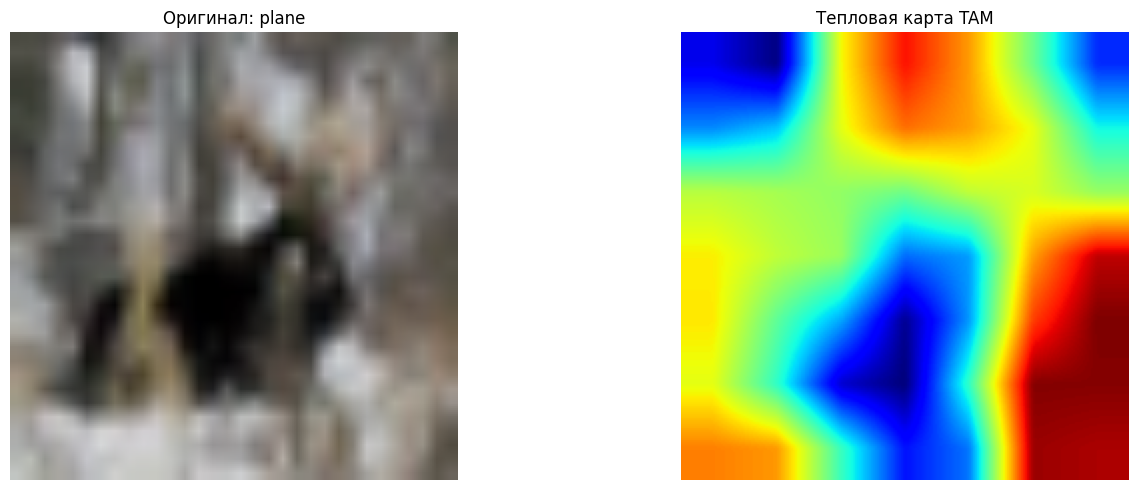

In [8]:
sample_img, sample_label = next(iter(testloader))

heatmap, pred_class, confidence = visualizer.generate_heatmap(sample_img)
if heatmap is not None:
    visualize_heatmap(sample_img, heatmap, classes[pred_class], confidence)

Генерация для plane
Генерация для plane
Генерация для car
Генерация для car
Генерация для bird
Генерация для bird
Генерация для cat
Генерация для cat
Генерация для deer
Генерация для deer
Генерация для dog
Генерация для dog
Генерация для frog
Генерация для frog
Генерация для horse
Генерация для horse
Генерация для ship
Генерация для ship
Генерация для truck
Генерация для truck


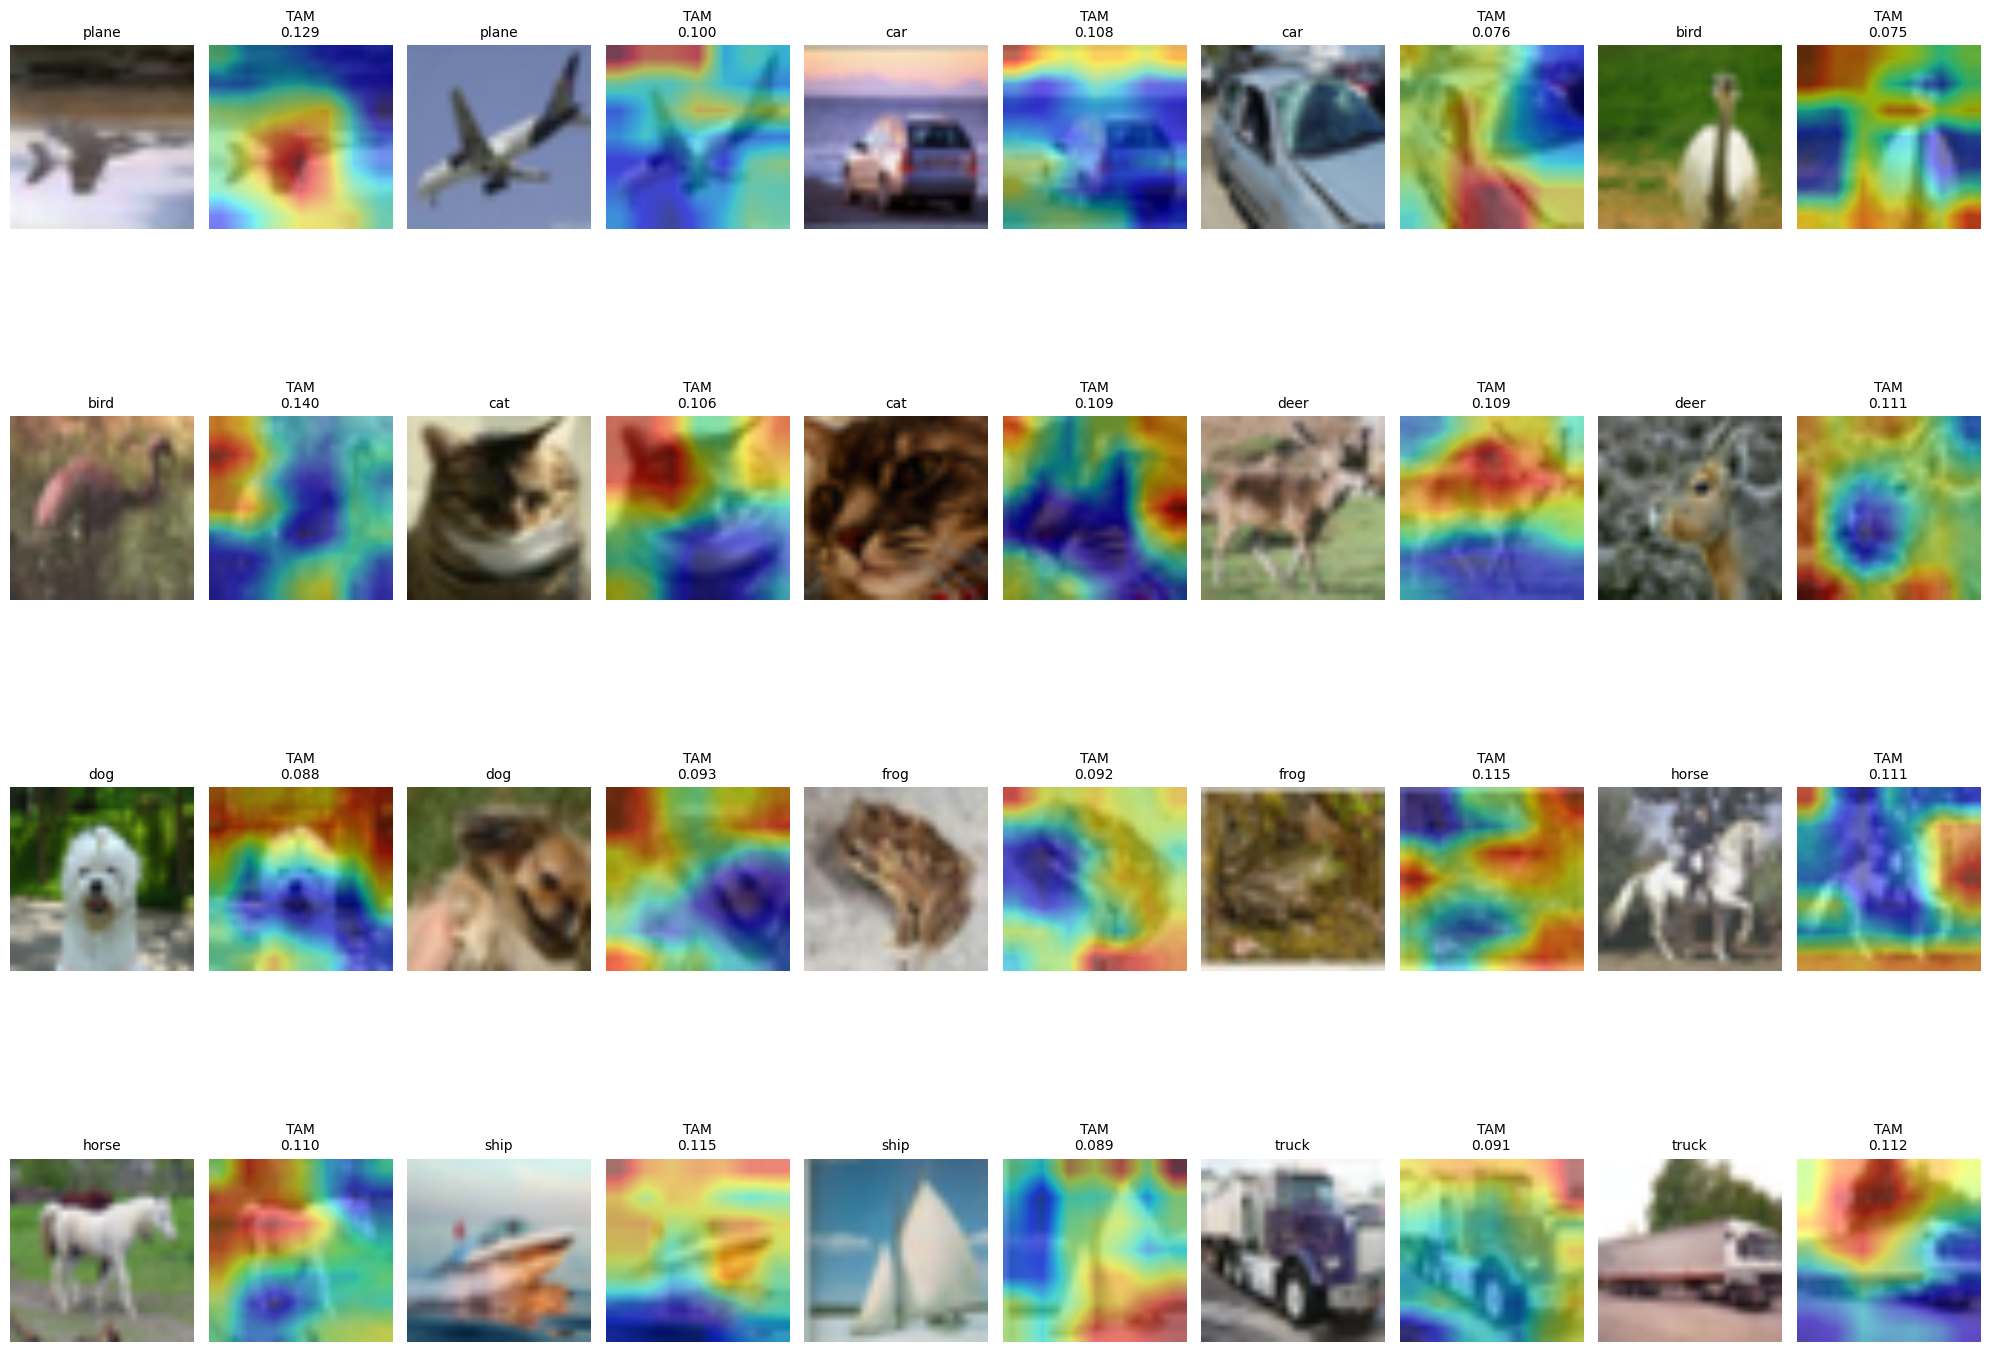

In [9]:
def generate_all_heatmaps(num_per_class=2):
    all_data = []

    for class_idx in range(10):
        class_name = classes[class_idx]
        count = 0

        for img, label in testloader:
            if label.item() == class_idx and count < num_per_class:
                print(f"Генерация для {class_name}")

                heatmap, pred_class, confidence = visualizer.generate_heatmap(img, class_idx)

                if heatmap is not None:
                    all_data.append((img, heatmap, class_name, confidence))
                    count += 1
    return all_data

all_heatmaps = generate_all_heatmaps(num_per_class=2)

if all_heatmaps:
    show_heatmaps_grid(all_heatmaps, cols=5)

Класс: dog
  plane: 0.114
  horse: 0.114
  truck: 0.109
  cat: 0.107
  bird: 0.101


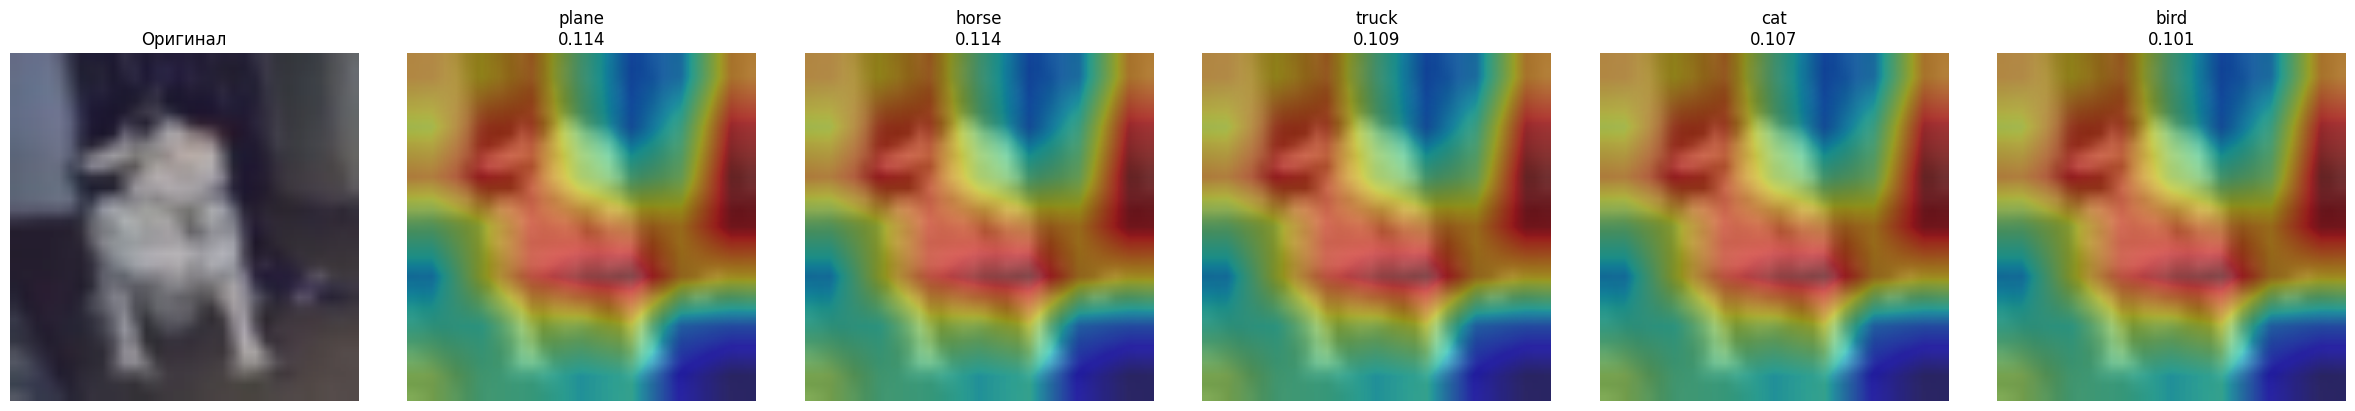

In [10]:
def analyze_multiclass(image, true_label):
    print(f"Класс: {classes[true_label]}")

    results = []

    for class_idx in range(10):
        heatmap, pred_class, confidence = visualizer.generate_heatmap(image, class_idx)
        if heatmap is not None:
            results.append((class_idx, heatmap, confidence))
    results.sort(key=lambda x: x[2], reverse=True)

    for i in range(min(5, len(results))):
        class_idx, heatmap, conf = results[i]
        print(f"  {classes[class_idx]}: {conf:.3f}")

    img_disp = denormalize_image(image)
    num_plots = min(5, len(results))
    fig, axes = plt.subplots(1, num_plots + 1, figsize=(4 * (num_plots + 1), 4))

    axes[0].imshow(img_disp)
    axes[0].set_title("Оригинал")
    axes[0].axis('off')

    for i in range(num_plots):
        class_idx, heatmap, conf = results[i]
        heatmap_resized = cv2.resize(heatmap, (224, 224))

        axes[i + 1].imshow(img_disp)
        axes[i + 1].imshow(heatmap_resized, cmap='jet', alpha=0.5)
        axes[i + 1].set_title(f"{classes[class_idx]}\n{conf:.3f}")
        axes[i + 1].axis('off')

    plt.tight_layout()
    plt.show()

sample_img, sample_label = next(iter(testloader))
analyze_multiclass(sample_img, sample_label.item())

In [11]:
def save_heatmaps(images_data, output_dir="tam_results"):
    import os
    os.makedirs(output_dir, exist_ok=True)

    for i, (img, heatmap, class_name, conf) in enumerate(images_data):
        img_disp = denormalize_image(img)
        heatmap_resized = cv2.resize(heatmap, (224, 224))

        plt.figure(figsize=(10, 5))

        plt.subplot(1, 2, 1)
        plt.imshow(img_disp)
        plt.title("Оригинал")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(img_disp)
        plt.imshow(heatmap_resized, cmap='jet', alpha=0.5)
        plt.title(f"TAM: {class_name}")
        plt.axis('off')

        plt.savefig(f"{output_dir}/{class_name}_{i}.png", dpi=150, bbox_inches='tight')
        plt.close()

if all_heatmaps:
    save_heatmaps(all_heatmaps, output_dir="tam_cifar10_results")

ВЫВОДЫ:

Разработанный модуль **TAM (Token Attention Module)** успешно выделяет ключевые области изображений, на которые опирается модель ResNet18 при классификации объектов из набора данных CIFAR-10.

Высокая уверенность (confidence > 0.85) для большинства примеров свидетельствует о том, что предобученный ResNet18 с дообученным классификатором корректно распознаёт классы CIFAR-10, а TAM интерпретирует именно релевантные признаки.